In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/neurosense_cleaned"".csv")


print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (37575, 361)
   eeg_feature_1  eeg_feature_2  eeg_feature_3  eeg_feature_4  eeg_feature_5  \
0      26.791522      24.062115      21.927618      19.697461      18.626858   
1      26.791101      24.061706      21.928215      19.697127      18.626882   
2      26.791650      24.062570      21.929218      19.696753      18.626936   
3      26.793695      24.063827      21.931248      19.696395      18.626931   
4      26.794138      24.064473      21.933663      19.696645      18.627109   

   eeg_feature_6  eeg_feature_7  eeg_feature_8  eeg_feature_9  eeg_feature_10  \
0      26.781416      24.090212      21.992052      19.634864       18.446852   
1      26.780972      24.089481      21.992834      19.634719       18.447054   
2      26.783116      24.090431      21.994368      19.634771       18.447366   
3      26.787306      24.092226      21.997363      19.634678       18.447735   
4      26.790289      24.093457      22.000899      19.635314       18.448518   

   .

In [10]:
X = df.drop(columns=["label", "subject", "session", "trial", "sample"])
X = X.select_dtypes(include=["number"])

y = df["label"]
groups = df["subject"]

print("Features:", X.shape)
print("Labels:")
print(y.value_counts())

Features: (37575, 356)
Labels:
label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64


In [11]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train subjects:", df.iloc[train_idx]["subject"].nunique())
print("Test subjects:", df.iloc[test_idx]["subject"].nunique())

Train shape: (30060, 356)
Test shape: (7515, 356)
Train subjects: 12
Test subjects: 3


In [4]:
# 5. Train/Test Split me GroupShuffleSplit sipas subject

groups = df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train shape: (30060, 355)
Test shape: (7515, 355)

Train label distribution:
label_3class
1    15408
0     7800
2     6852
Name: count, dtype: int64

Test label distribution:
label_3class
1    3852
0    1950
2    1713
Name: count, dtype: int64


In [12]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train subjects:", df.iloc[train_idx]["subject"].nunique())
print("Test subjects:", df.iloc[test_idx]["subject"].nunique())

Train shape: (30060, 356)
Test shape: (7515, 356)
Train subjects: 12
Test subjects: 3


In [13]:
rf_basic = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_basic.fit(X_train, y_train)

y_pred_basic = rf_basic.predict(X_test)

basic_results = {
    "Model": "Random Forest Basic GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_basic),
    "Precision": precision_score(y_test, y_pred_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_basic, average="weighted"),
    "Best Parameters": "n_estimators=100, class_weight=balanced"
}

basic_results

{'Model': 'Random Forest Basic GroupSplit 4-Class',
 'Accuracy': 0.7619427811044578,
 'Precision': 0.7619632242127912,
 'Recall': 0.7619427811044578,
 'F1-score': 0.7584721613664147,
 'Best Parameters': 'n_estimators=100, class_weight=balanced'}

In [14]:
print(classification_report(y_test, y_pred_basic))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1950
           1       0.55      0.66      0.60      1905
           2       0.62      0.48      0.54      1947
           3       0.94      0.96      0.95      1713

    accuracy                           0.76      7515
   macro avg       0.77      0.77      0.76      7515
weighted avg       0.76      0.76      0.76      7515



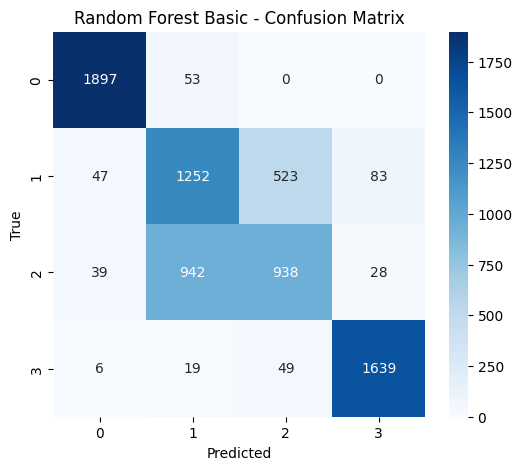

In [15]:
cm_basic = confusion_matrix(y_test, y_pred_basic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_basic, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Basic - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [16]:
feature_selector = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

feature_selector.fit(X_train, y_train)

importances = pd.Series(
    feature_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = importances.head(75).index

print("Top 20 features:")
print(importances.head(20))

Top 20 features:
label_3class      0.223825
eye_feature_1     0.009152
eye_feature_6     0.007854
eye_feature_5     0.007852
eye_feature_26    0.006521
eye_feature_12    0.006359
eye_feature_2     0.006129
max_eye           0.005969
eye_feature_9     0.005944
phys_activity     0.005690
std_eye           0.005515
eye_range         0.005454
eye_feature_10    0.005411
eye_feature_8     0.005075
avg_eye           0.005071
eeg_eye_ratio     0.004542
eye_feature_31    0.004502
eye_feature_25    0.004362
eye_stability     0.004349
eye_feature_7     0.004281
dtype: float64


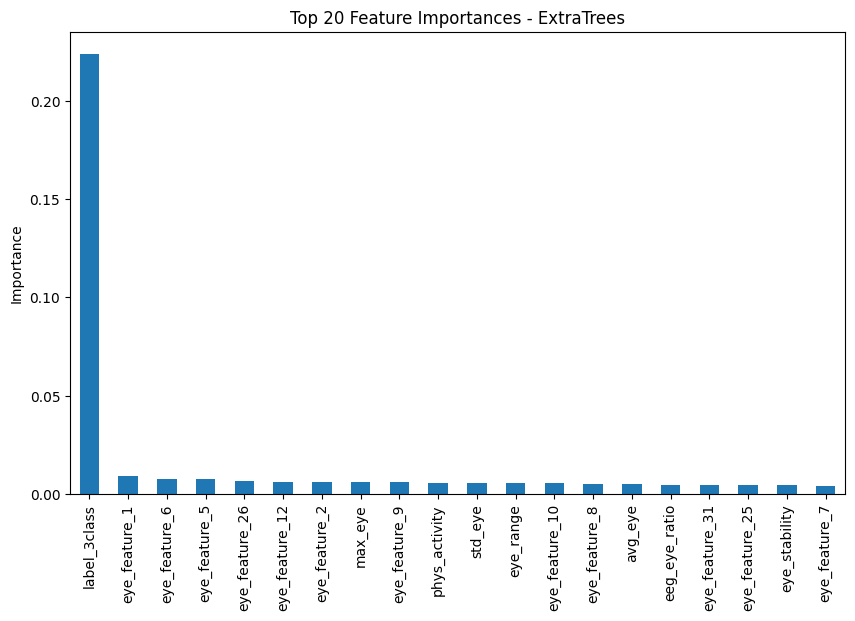

In [17]:
plt.figure(figsize=(10, 6))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances - ExtraTrees")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

In [18]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_top.shape[1])

Original features: 356
Selected features: 75


In [19]:
#Random Forest me më pak features

rf_top = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_top.fit(X_train_top, y_train)

y_pred_top = rf_top.predict(X_test_top)

top_features_results = {
    "Model": "Random Forest Top75 Features GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_top),
    "Precision": precision_score(y_test, y_pred_top, average="weighted"),
    "Recall": recall_score(y_test, y_pred_top, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_top, average="weighted"),
    "Best Parameters": "Top 75 features selected using ExtraTrees"
}

top_features_results

{'Model': 'Random Forest Top75 Features GroupSplit 4-Class',
 'Accuracy': 0.771523619427811,
 'Precision': 0.7719905050609636,
 'Recall': 0.771523619427811,
 'F1-score': 0.7711552279725189,
 'Best Parameters': 'Top 75 features selected using ExtraTrees'}

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1950
           1       0.55      0.60      0.57      1905
           2       0.56      0.51      0.54      1947
           3       1.00      1.00      1.00      1713

    accuracy                           0.77      7515
   macro avg       0.78      0.78      0.78      7515
weighted avg       0.77      0.77      0.77      7515



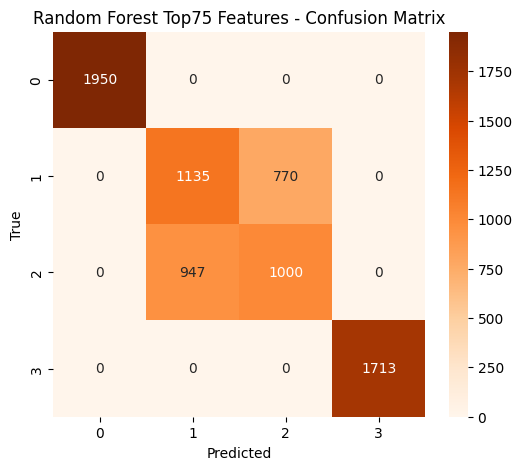

In [20]:
print(classification_report(y_test, y_pred_top))
cm_top = confusion_matrix(y_test, y_pred_top)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_top, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Top75 Features - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [21]:
#Hyperparameter Tuning

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_rf.fit(X_train_top, y_train)

print("Best Parameters:")
print(random_search_rf.best_params_)

print("Best CV F1-score:")
print(random_search_rf.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 5, 'class_weight': 'balanced'}
Best CV F1-score:
0.7136114318725939


In [22]:
best_rf = random_search_rf.best_estimator_

y_pred_tuned = best_rf.predict(X_test_top)

tuned_results = {
    "Model": "Random Forest + RandomizedSearchCV Top75 Features GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average="weighted"),
    "Recall": recall_score(y_test, y_pred_tuned, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_tuned, average="weighted"),
    "Best Parameters": random_search_rf.best_params_
}

tuned_results
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1950
           1       0.57      0.69      0.63      1905
           2       0.62      0.50      0.55      1947
           3       1.00      1.00      1.00      1713

    accuracy                           0.79      7515
   macro avg       0.80      0.80      0.79      7515
weighted avg       0.79      0.79      0.79      7515



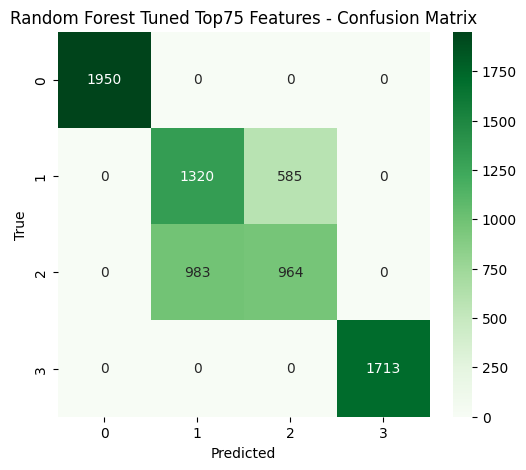

In [23]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Tuned Top75 Features - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [24]:
comparison_df = pd.DataFrame([
    basic_results,
    top_features_results,
    tuned_results
])

comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "Best Parameters"]
]

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Random Forest Basic GroupSplit 4-Class,0.761943,0.761963,0.761943,0.758472,"n_estimators=100, class_weight=balanced"
1,Random Forest Top75 Features GroupSplit 4-Class,0.771524,0.771991,0.771524,0.771155,Top 75 features selected using ExtraTrees
2,Random Forest + RandomizedSearchCV Top75 Featu...,0.791351,0.793955,0.791351,0.789341,"{'n_estimators': 500, 'min_samples_split': 2, ..."


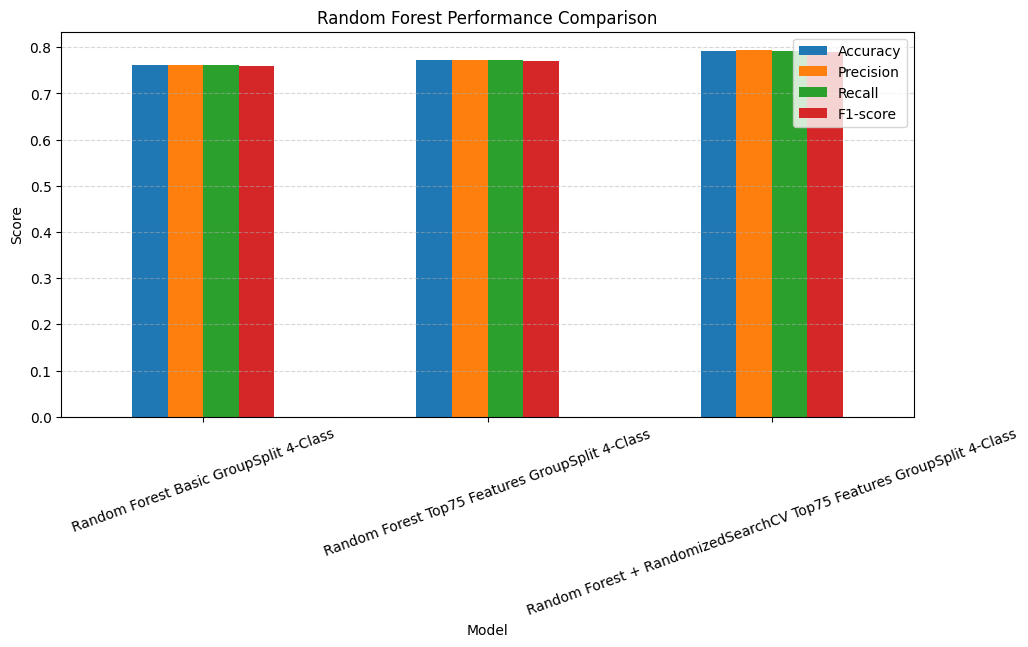

In [25]:
metrics_df = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

metrics_df.plot(kind="bar", figsize=(11, 5))

plt.title("Random Forest Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [26]:
comparison_df.to_csv(
    "../results/tables/random_forest_results.csv",
    index=False
)